In [1]:
import pandas as pd
df=pd.read_csv("../data/raw/fake_job_postings.csv")
print(df.head)
a=df['fraudulent'].value_counts()
print(a)
df.isnull().sum().sort_values(ascending=False)

<bound method NDFrame.head of        job_id                                              title  \
0           1                                   Marketing Intern   
1           2          Customer Service - Cloud Video Production   
2           3            Commissioning Machinery Assistant (CMA)   
3           4                  Account Executive - Washington DC   
4           5                                Bill Review Manager   
...       ...                                                ...   
17875   17876                   Account Director - Distribution    
17876   17877                                 Payroll Accountant   
17877   17878  Project Cost Control Staff Engineer - Cost Con...   
17878   17879                                   Graphic Designer   
17879   17880                         Web Application Developers   

                   location   department salary_range  \
0          US, NY, New York    Marketing          NaN   
1            NZ, , Auckland      Succes

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64

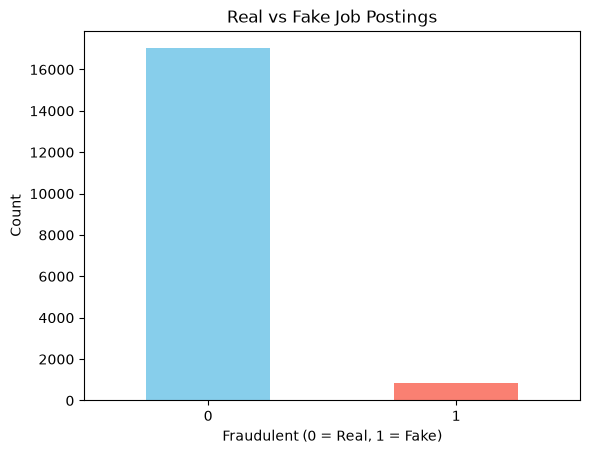

In [2]:
import matplotlib.pyplot as plt

df['fraudulent'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Real vs Fake Job Postings')
plt.xlabel('Fraudulent (0 = Real, 1 = Fake)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [3]:
x=df.columns.tolist()
for col in x:
    missing_rate = df.groupby('fraudulent')[col].apply(lambda x: x.isnull().mean())
    print(f"\n{col} — missing rate by class:")
    print(missing_rate)


job_id — missing rate by class:
fraudulent
0    0.0
1    0.0
Name: job_id, dtype: float64

title — missing rate by class:
fraudulent
0    0.0
1    0.0
Name: title, dtype: float64

location — missing rate by class:
fraudulent
0    0.019219
1    0.021940
Name: location, dtype: float64

department — missing rate by class:
fraudulent
0    0.647467
1    0.613164
Name: department, dtype: float64

salary_range — missing rate by class:
fraudulent
0    0.844540
1    0.742494
Name: salary_range, dtype: float64

company_profile — missing rate by class:
fraudulent
0    0.159927
1    0.677829
Name: company_profile, dtype: float64

description — missing rate by class:
fraudulent
0    0.000000
1    0.001155
Name: description, dtype: float64

requirements — missing rate by class:
fraudulent
0    0.149406
1    0.177829
Name: requirements, dtype: float64

benefits — missing rate by class:
fraudulent
0    0.402492
1    0.420323
Name: benefits, dtype: float64

telecommuting — missing rate by class:
fraud

In [4]:
df["salary_missing"] = df["salary_range"].isna().astype(int)
df.drop(columns=["salary_range"], inplace=True)
df["salary_missing"].head()
#1: salary missing, 0: salary available

0    1
1    1
2    1
3    1
4    1
Name: salary_missing, dtype: int64

In [5]:
df = df.drop(columns=['job_id', 'department'])

In [6]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

In [7]:
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [8]:
df['location_missing'] = df['location'].isna().astype(int)
df['country'] = df['location'].fillna('Unknown').apply(
    lambda x: x.split(',')[0].strip() if x != 'Unknown' else 'Unknown'
)
df = df.drop(columns=['location'])

In [9]:
print(df.isnull().sum())

title                  0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
salary_missing         0
location_missing       0
country                0
dtype: int64


In [11]:
df.to_csv('emscad_cleaned.csv', index=False)